Happiness is a complex and multifaceted concept, but what if we could quantify it? The World Happiness Report attempts to do just that by ranking countries based on various factors that contribute to overall well-being. In this notebook, we'll dive into the World Happiness data from 2015 to 2019 to uncover insights and trends. If you find this analysis useful, please consider upvoting it.

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
df_2015 = pd.read_csv('/kaggle/input/world-happiness/2015.csv')
df_2016 = pd.read_csv('/kaggle/input/world-happiness/2016.csv')
df_2017 = pd.read_csv('/kaggle/input/world-happiness/2017.csv')
df_2018 = pd.read_csv('/kaggle/input/world-happiness/2018.csv')
df_2019 = pd.read_csv('/kaggle/input/world-happiness/2019.csv')

### Data Overview
Let's take a quick look at the first few rows of each dataset to understand their structure.

In [3]:
df_2015.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [4]:
df_2016.head()

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


In [5]:
df_2017.head()

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182


In [6]:
df_2018.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408
3,4,Iceland,7.495,1.343,1.644,0.914,0.677,0.353,0.138
4,5,Switzerland,7.487,1.420,1.549,0.927,0.660,0.256,0.357


In [7]:
df_2019.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


### Data Cleaning and Preparation
We need to standardize the column names across all datasets for consistency.

In [8]:
# Standardize column names
df_2015.columns = ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
df_2016.columns = ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
df_2017.columns = ['Country', 'Happiness Rank', 'Happiness Score', 'Whisker High', 'Whisker Low', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Generosity', 'Trust (Government Corruption)', 'Dystopia Residual']
df_2018.columns = ['Overall Rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
df_2019.columns = ['Overall Rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

### Exploratory Data Analysis
Let's start by visualizing the distribution of happiness scores across different years.

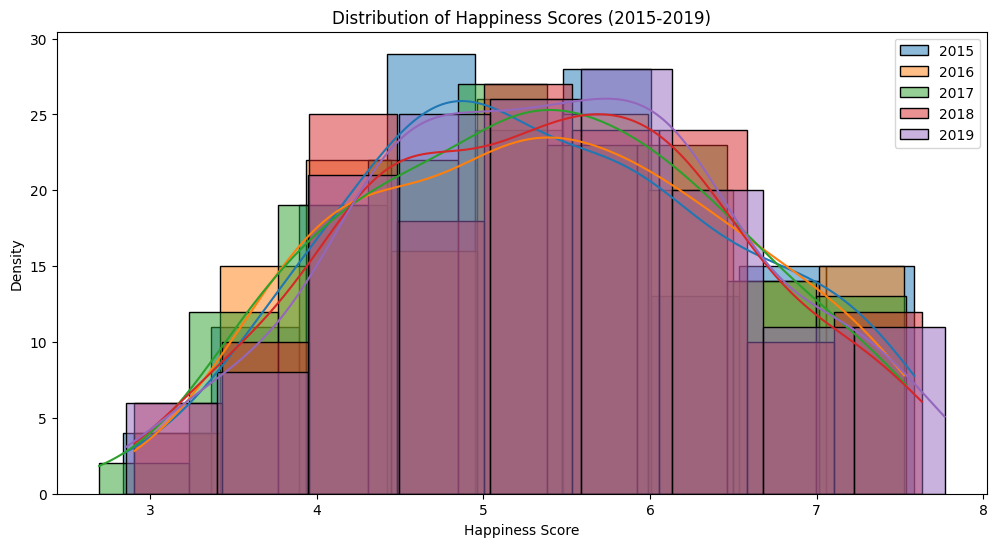

In [9]:
plt.figure(figsize=(12, 6))
sns.histplot(df_2015['Happiness Score'], kde=True, label='2015')
sns.histplot(df_2016['Happiness Score'], kde=True, label='2016')
sns.histplot(df_2017['Happiness Score'], kde=True, label='2017')
sns.histplot(df_2018['Score'], kde=True, label='2018')
sns.histplot(df_2019['Score'], kde=True, label='2019')
plt.legend()
plt.title('Distribution of Happiness Scores (2015-2019)')
plt.xlabel('Happiness Score')
plt.ylabel('Density')
plt.show()

### Correlation Analysis
Let's examine the correlation between different factors and the happiness score for each year.

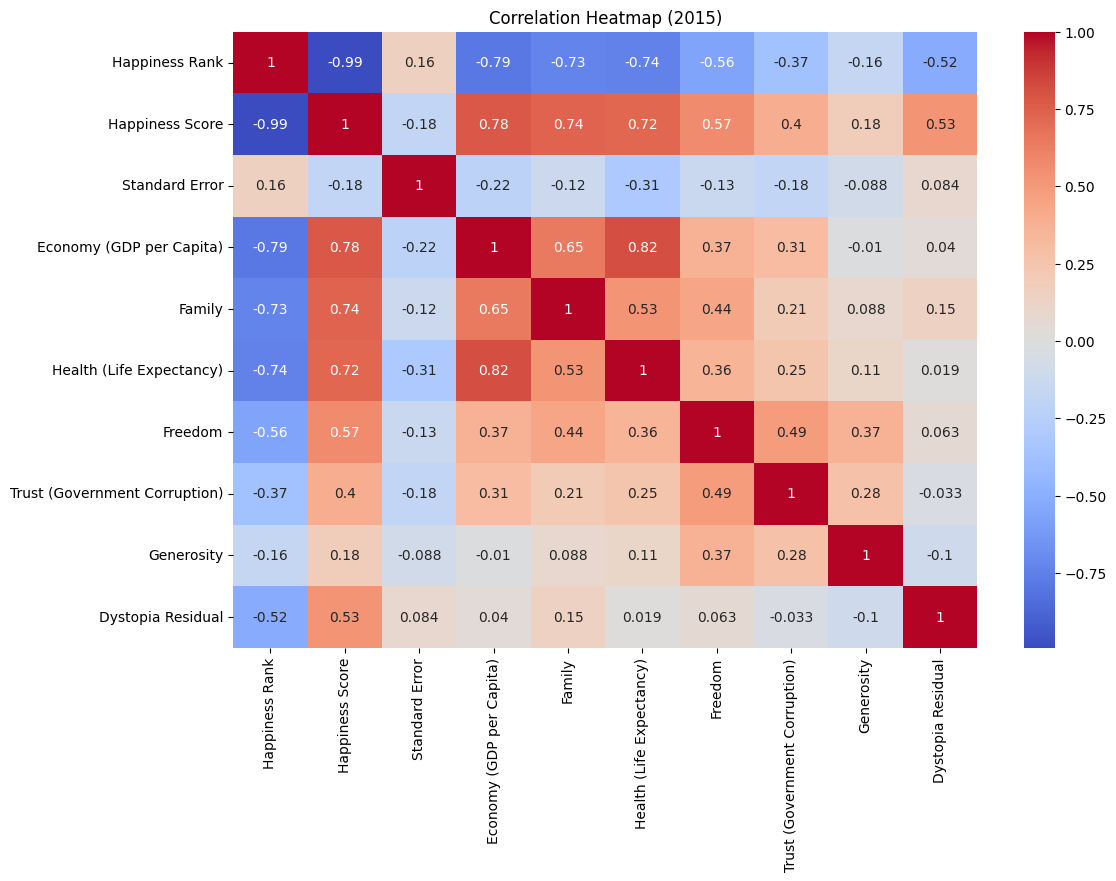

In [10]:
# Correlation heatmap for 2015
numeric_df_2015 = df_2015.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df_2015.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (2015)')
plt.show()

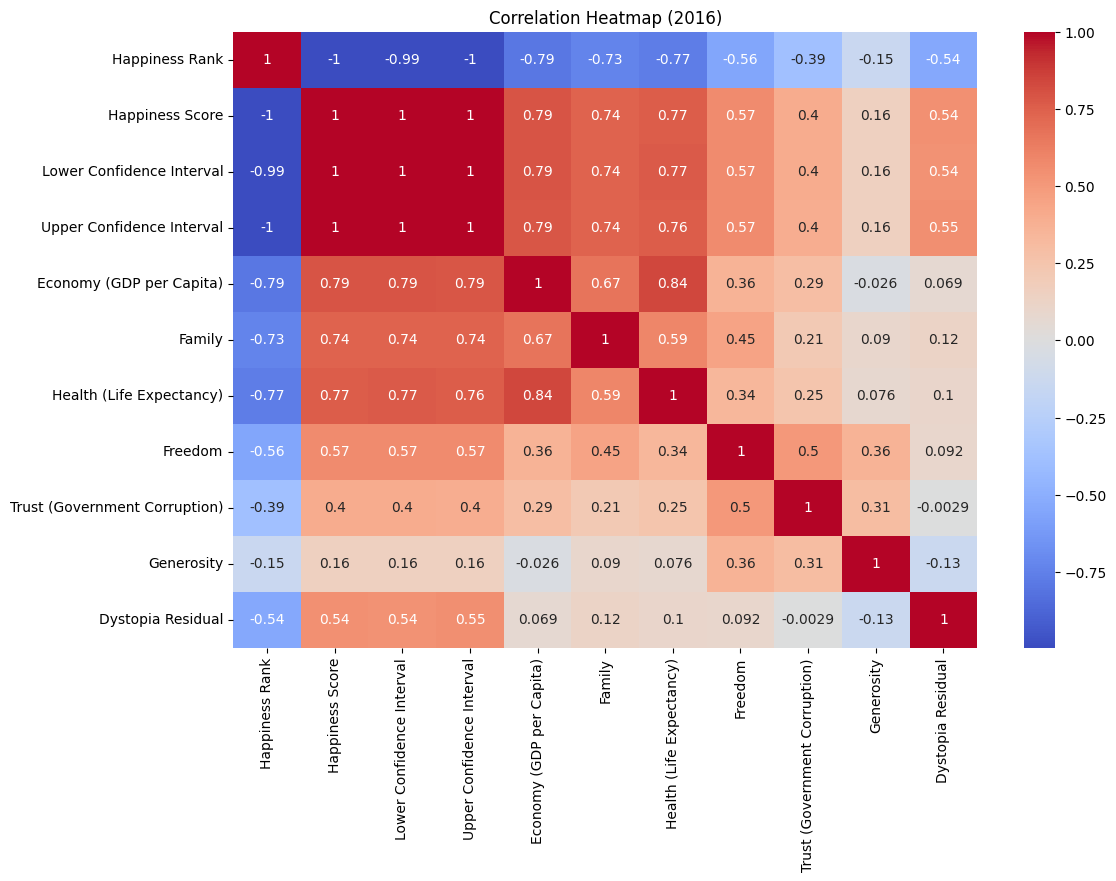

In [11]:
# Correlation heatmap for 2016
numeric_df_2016 = df_2016.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df_2016.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (2016)')
plt.show()

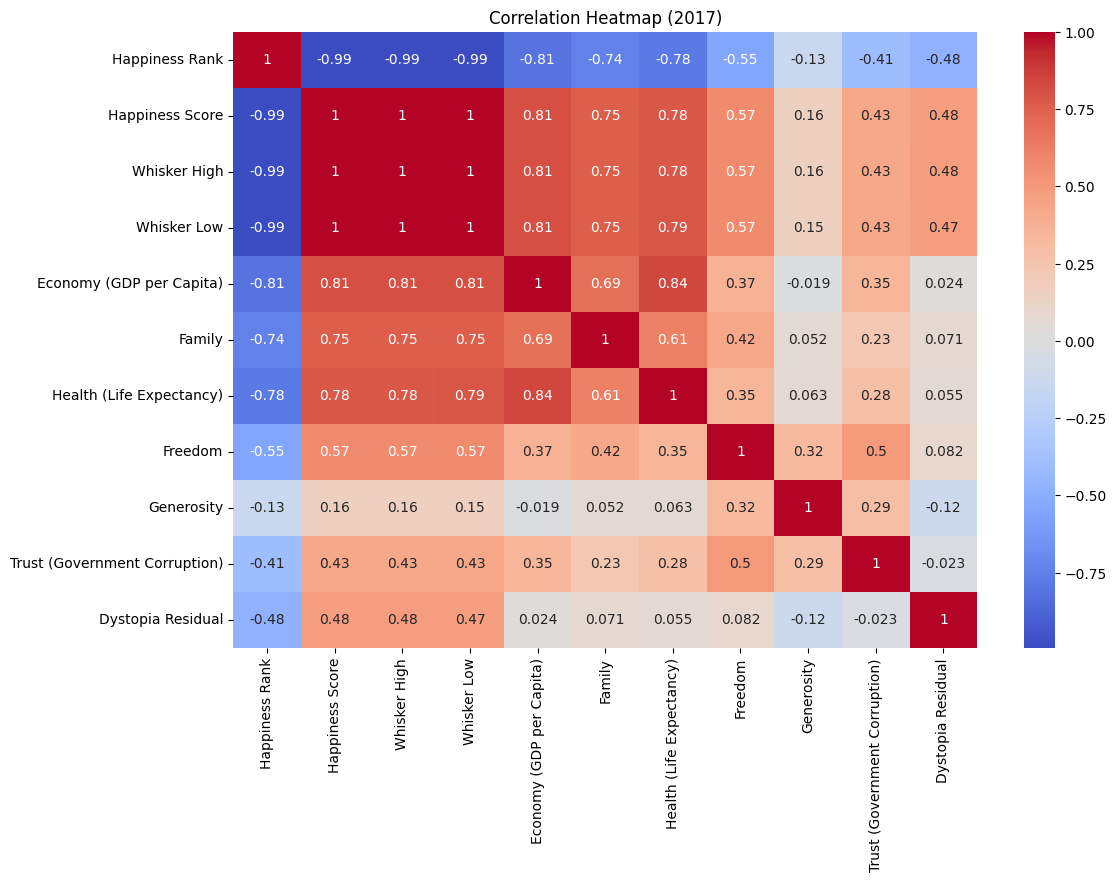

In [12]:
# Correlation heatmap for 2017
numeric_df_2017 = df_2017.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df_2017.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (2017)')
plt.show()

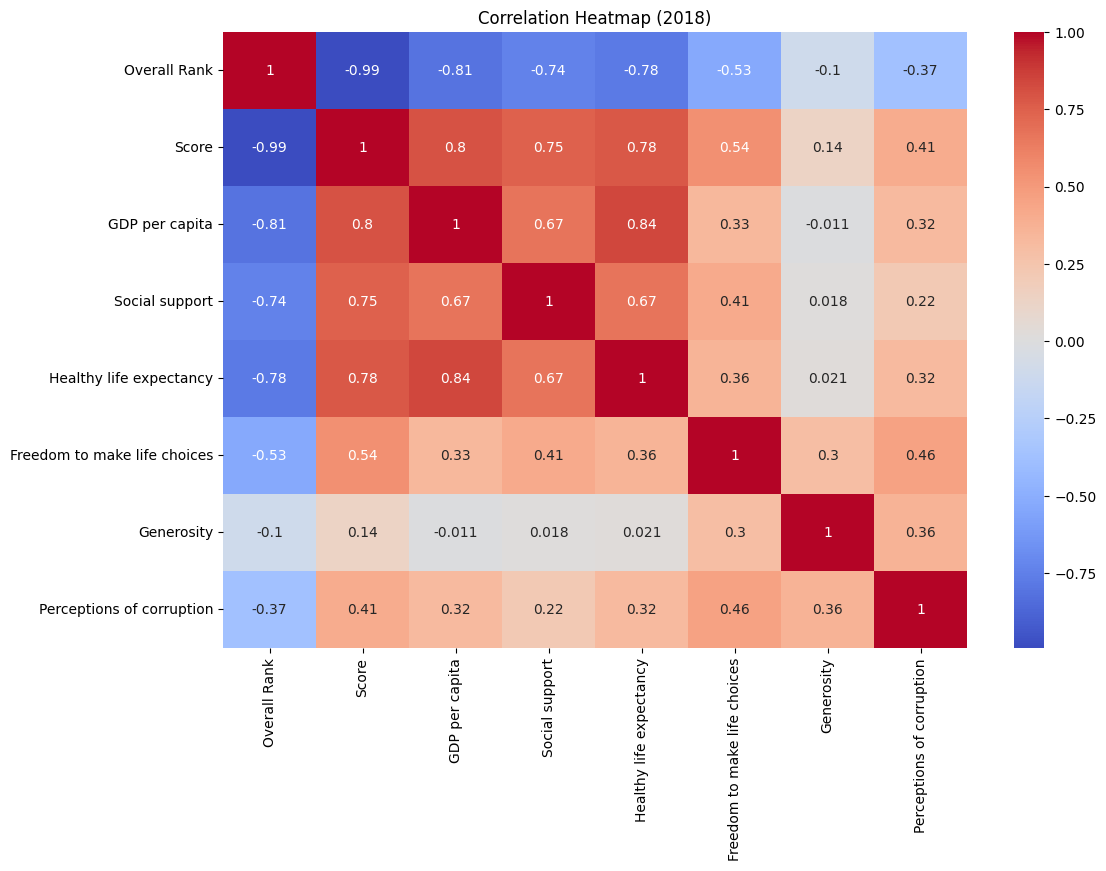

In [13]:
# Correlation heatmap for 2018
numeric_df_2018 = df_2018.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df_2018.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (2018)')
plt.show()

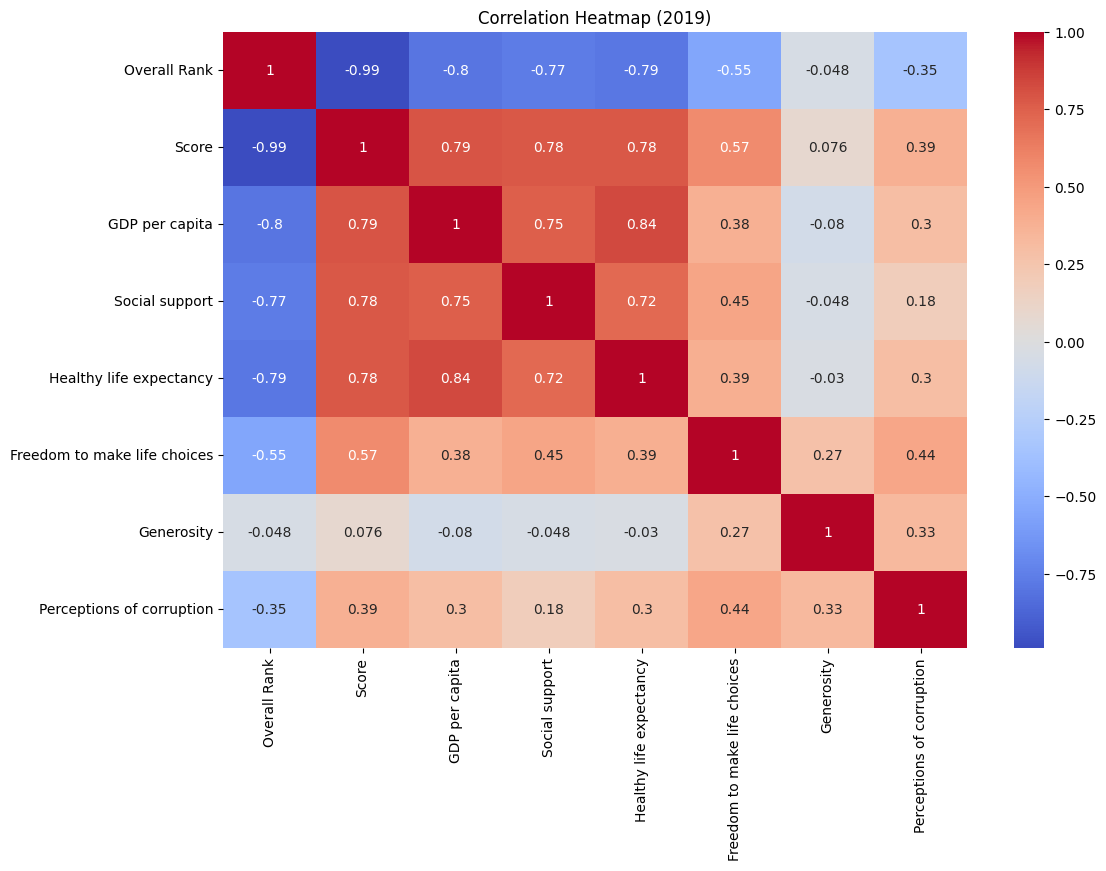

In [14]:
# Correlation heatmap for 2019
numeric_df_2019 = df_2019.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df_2019.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (2019)')
plt.show()

### Predictive Modeling
Given the data, it would be interesting to predict the happiness score based on the other factors. Let's build a simple linear regression model to do this.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Prepare the data for 2019
X = df_2019[['GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']]
y = df_2019['Score']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse, r2

(0.4144641383528352, 0.6017537913445683)

### Conclusion and Future Work
In this notebook, we explored the World Happiness data from 2015 to 2019, visualized the distribution of happiness scores, examined correlations, and built a simple predictive model. There are many avenues for future analysis, such as exploring regional trends, examining changes over time, or using more advanced machine learning models for prediction.

What do you think would be useful to explore next? Let me know in the comments.

## Credits
This notebook was created with the help of [Devra AI data science assistant](https://devra.ai/ref/kaggle)